In [1]:
import torch
import os
import argparse
import copy

models_dir = "trained_models"

model_metadata = {}

for root, _, files in os.walk(models_dir):  
    for filename in files:
        if filename.endswith('.pth'):
            checkpoint_path = os.path.join(root, filename)
            
            torch.serialization.add_safe_globals([argparse.Namespace])
            checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
            
            model_metadata[str(filename)] = {
                k: copy.deepcopy(v) 
                for k, v in checkpoint.items() 
                if k != "model"
            }

In [2]:
from pprint import pprint

models = model_metadata.keys()

print("Models: ", models)
print("Sample Model Dict: ")
pprint(model_metadata[list(models)[0]])

Models:  dict_keys(['resnet10t_baseline.pth', 'resnet18_baseline.pth', 'resnet50_baseline.pth'])
Sample Model Dict: 
{'epoch': 10,
 'epoch_time_history': [21.136942625045776,
                        21.13392972946167,
                        21.10490655899048,
                        21.10923171043396,
                        21.08938717842102,
                        21.11753225326538,
                        21.131874322891235,
                        21.143914937973022,
                        21.111928462982178,
                        21.13340997695923],
 'loss_history': [2.8556889306174384,
                  1.346951056321462,
                  0.9159521222114563,
                  0.7256439913643731,
                  0.5939351438151466,
                  0.5307258684105344,
                  0.46485589199595984,
                  0.39674571275711057,
                  0.3678115514251921,
                  0.346186631653044],
 'model_name': 'resnet10t_baseline',
 'train_f1_histo

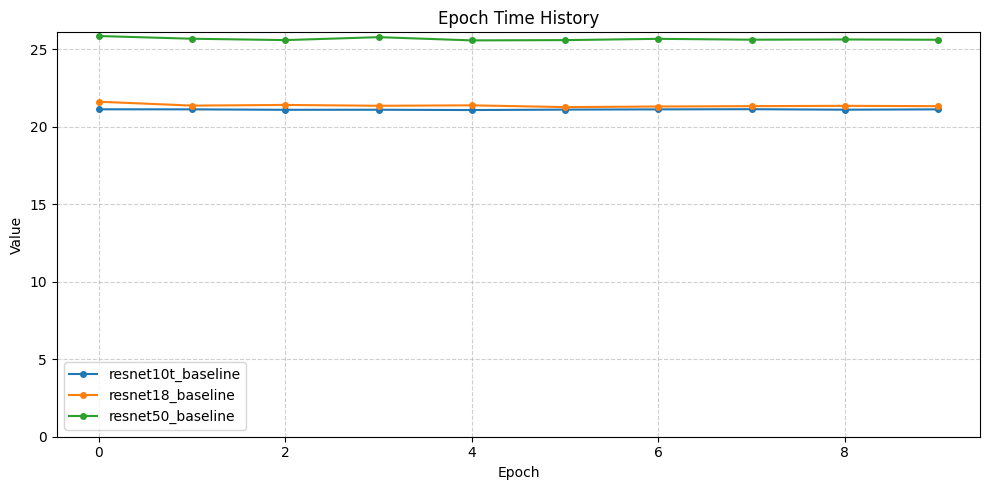

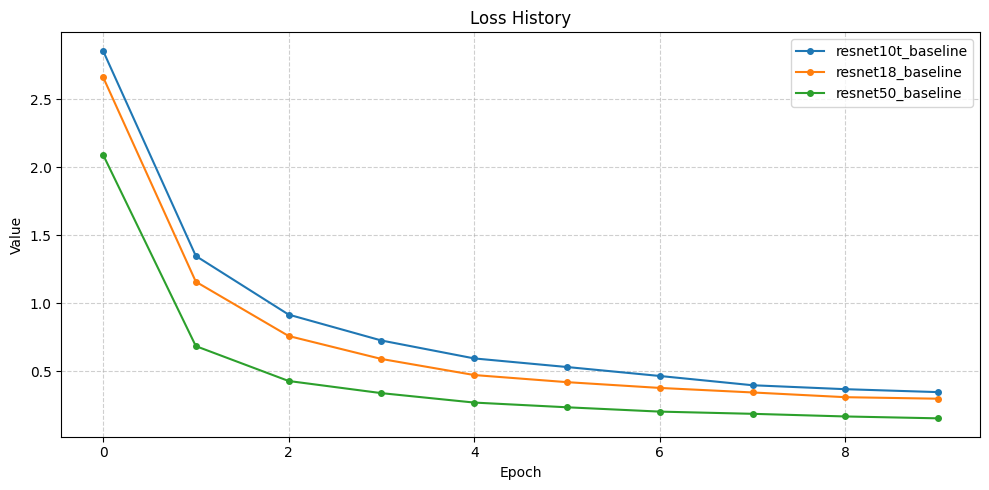

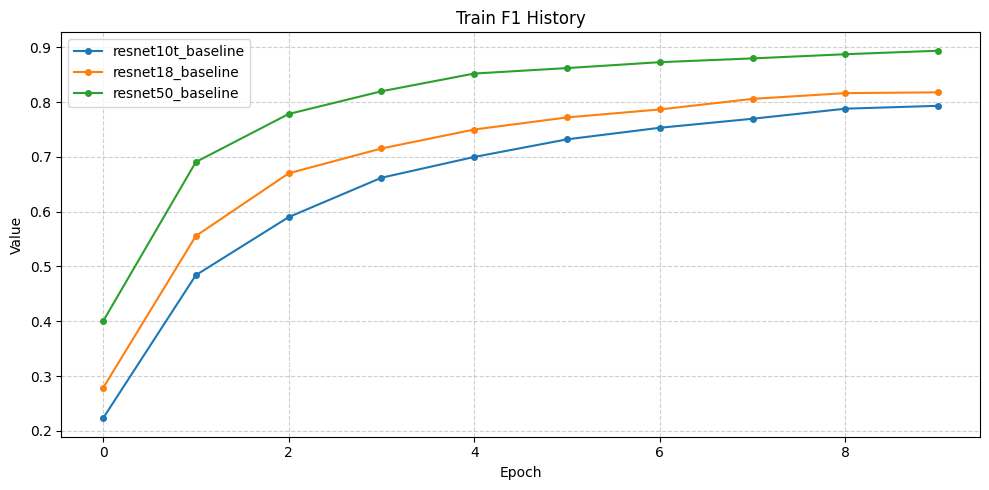

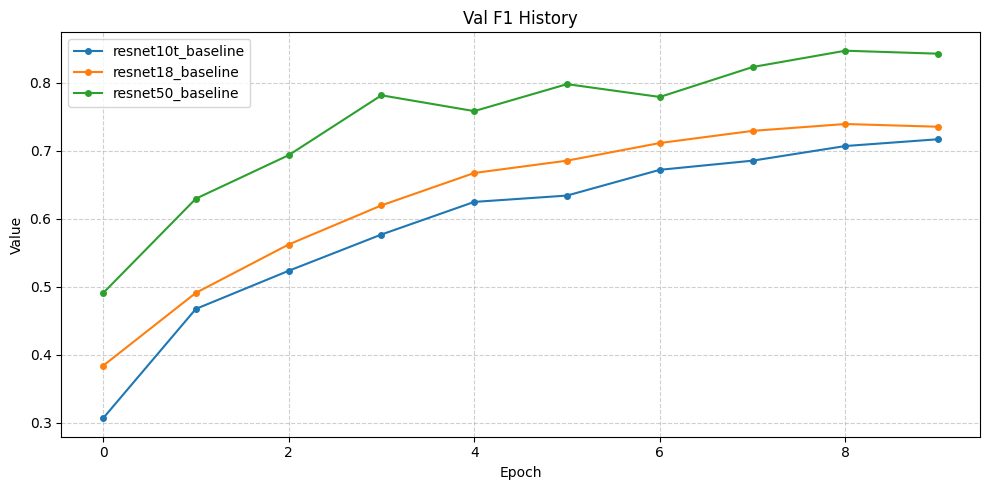

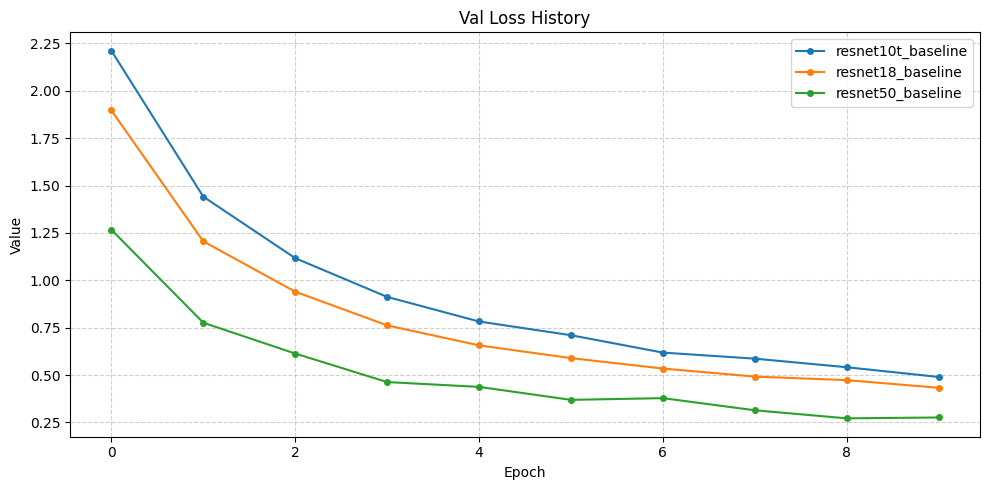

In [4]:
import matplotlib.pyplot as plt

metrics = {key for model in model_metadata.values() for key in model if 'history' in key}

for metric in sorted(metrics):
    plt.figure(figsize=(10, 5))
    
    for model_filename, data in model_metadata.items():
        if metric in data:
            label = data.get('model_name', model_filename)
            plt.plot(data[metric], label=label, marker='o', markersize=4)
    
    plt.title(f"{metric.replace('_', ' ').title()}")
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    if metric == "epoch_time_history":
        plt.ylim(bottom=0)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()